# Week1 Lecture4: Python as Modelling and Simulation Tool

## 1. Datatypes and Variables

The following code demonstrates how variables store different types of data in Python.

* `robot_name` stores text using a **string**.
* `max_speed` stores a **float** (decimal number).
* `time` stores an **integer** (whole number).

It also shows data structures that hold multiple values:

* `sensor_data` is a **list** of sensor readings.
* `robot_pose` is a **tuple** representing position values.
* `objects` is a **set** that stores **unique items**, automatically removing duplicates.


In [ ]:
robot_name = "mobile robot"           # string
max_speed = 1.5                 # float
time = 4                        # int

sensor_data = [1.2, 1.5, 0.9, 2.0]	            # lists
robot_pose = (2.3, 1.2, 0.5)		            # tuple
objects = {"chair", "table", "wall", "chair"}	# set

## 2. Functions and Arguments

The following code defines a function called `compute_distance` that calculates distance using speed and time.

* `speed` and `time` are **arguments** passed to the function.
* Inside the function, distance is calculated using `speed * time`.
* The result is returned using the `return` statement.

The function is then called with values `10` and `5`, and the computed distance is stored in `d` and printed.

In [61]:
def compute_distance(speed, time):
    distance = speed * time
    return distance

d = compute_distance(10, 5)

print(d)

50


## 3. Modules

The built-in `math` module is imported to access common mathematical functions and constants.

* `math.pi` provides the constant value of **π**.
* `math.sqrt(441)` calculates the **square root** of 441.

The `print()` statements display these values as output.

In [62]:
import math

math.pi
math.sqrt(441)

print(math.pi)
print(math.sqrt(441))

3.141592653589793
21.0


## 4. Operators and Control Statements

The code demonstrates the use of **operators** and **control statements** to make decisions based on sensor readings.

* **Relational operators** (e.g., `<`) compare the sensor distance values.
* **Control statements** like `for`, `if`, `break`, and `continue` control how the program executes.

The program iterates through `sensor_data` (a list of distance readings) and decides the robot's action:

* If the distance is **less than 0.5**, the robot **stops** and exits the for loop using `break`.
* If the distance is **less than 1.0**, the robot **reduces speed** and moves to the next reading using `continue`.
* Otherwise, the robot **moves forward**.

This logic simulates how a robot can adjust its behavior based on sensor data.

In [63]:
sensor_data = [2.0, 1.5, 0.8, 0.4, 0.2] # list class

for reading in sensor_data:

    if reading < 0.5:
        action = "STOP"
        break                           # comes out of for-loop

    if reading < 1.0:
        action = "Reduce speed"
        print("Distance:", reading, "Robot action:", action)
        continue # jumps to next iteration
    else:
        action = "MOVE_FORWARD"

    print("Distance:", reading, "Robot action:", action)

print("Distance:", reading, "Final Robot action:", action)

Distance: 2.0 Robot action: MOVE_FORWARD
Distance: 1.5 Robot action: MOVE_FORWARD
Distance: 0.8 Robot action: Reduce speed
Distance: 0.4 Final Robot action: STOP


## 5. Objects and Class

The code defines a **class `Robot`**, which acts as a template for creating robot objects.

* The class contains **attributes** (`name`, `speed`) that store robot information.
* It also defines **methods** (`move`, `status`) that describe the robot's behavior.
* The `__init__` method initializes the object when it is created.

An object `robot1` is created from the `Robot` class with a name and speed.
The methods `status()` and `move()` are then called to display the robot's details and simulate its movement.


In [64]:
class Robot:
    def __init__(self, name, speed):
        self.name = name
        self.speed = speed

    def move(self, time, action="moved"):
        distance = self.speed * time
        print(self.name, action, distance, "meters")

    def status(self):
        print("Robot:", self.name)
        print("Speed:", self.speed)

robot1 = Robot("robot 1", 1.5)

robot1.status()
print('----')
robot1.move(4)

Robot: robot 1
Speed: 1.5
----
robot 1 moved 6.0 meters


## 6. Class inheritance and Polymorphism

The code demonstrates **inheritance**, where new classes are created from an existing class.
`MobileRobot` and `Drone` are **child classes** that inherit attributes (`name`, `speed`) and methods from the parent class `Robot`.

It also illustrates **polymorphism**, where child classes define a method with the **same name** as in the parent class but with different behavior.

* `MobileRobot` overrides `move()` to show that the robot **drives**.
* `Drone` overrides `move()` and uses `super()` to reuse the parent method while changing the action to **flies**.

Objects `r1` and `r2` are created from the child classes, and calling `move()` produces different behaviors depending on the object type.


In [65]:
class MobileRobot(Robot):
    def move(self, time):
        distance = self.speed * time
        print(self.name, "drives", distance, "m")

class Drone(Robot):
    def move(self, time):
        super().move(time, "flies")

r1 = MobileRobot("rover", 1.5)
r2 = Drone("quadrotor", 3.5)

r1.move(3)
r2.move(3)

rover drives 4.5 m
quadrotor flies 10.5 meters


## 7. Numerical Computation

This example demonstrates how scientific Python packages can be used to simulate a robot moving in a 2D environment.

* **NumPy** is used to represent the robot pose, goal position, and motion steps as numerical arrays.
* The robot starts at position `[0, 0]` and moves toward the goal `[5, 4]` using incremental motion steps.
* After each motion, the updated robot position is **appended to a list** called `path` to store the full trajectory.
* The list of poses is then converted into a NumPy array for easier numerical operations.
* **SciPy** is used to compute the **Euclidean distance** between the robot’s final position and the goal.
* Finally, **Matplotlib** visualizes the robot’s path and the goal position on a 2D plot.

This program illustrates how numerical computation, scientific algorithms, and visualization can be combined to analyze robot movement.

Final robot position: [4. 3.]
Distance to goal: 1.4142135623730951


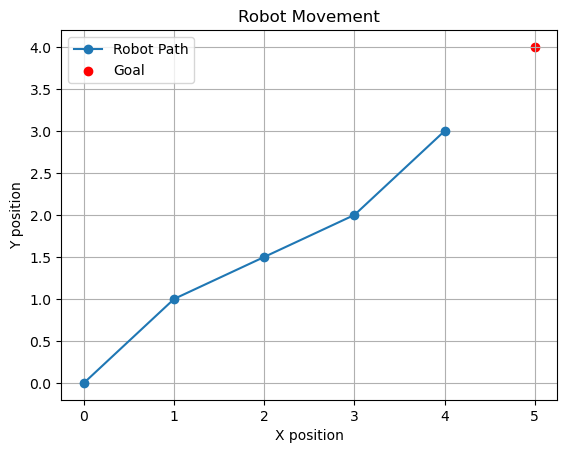

In [66]:
# import necessary packages
import numpy as np
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

# robot starting position
pose = np.array([0,0])

# goal position
goal = np.array([5, 4])

# robot movements (dx, dy)
motions = np.array([[1,1],[1,0.5],[1,0.5],[1,1]])

# store robot path
path = [pose]   # initiating a list 

# update robot position
for m in motions:
    pose = pose + m

    # append the updated pose to the path
    path.append(pose)

# convert list to numpy array
path = np.array(path) 

# compute distance to goal using SciPy
dist = euclidean(path[-1], goal)

print("Final robot position:", path[-1])
print("Distance to goal:", dist)

# visualize robot path
plt.plot(path[:,0], path[:,1], 'o-', label="Robot Path")
plt.scatter(goal[0], goal[1], color='red', label="Goal")

plt.title("Robot Movement")
plt.xlabel("X position")
plt.ylabel("Y position")
plt.grid(True)
plt.legend()

plt.show()